1. dividing the data to bins/sliding windows 
2. calculating the linear model
    a) add weighting per window to match sample to population - using balance package, and post-stratification weighting (to match the known distribution based on the israeli Central Bureau of Statistic )
3. creating coef_df (for each linear model summary - coefficients etc.) - run if not using the coef_df created in step9

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from balance import Sample

# --- CONFIGURATION ---
min_age = 20
max_age = 100

# Windowing strategy options: 'fixed', 'manual', 'sliding_n_subjects', 'sliding_n_years'
STRATEGY = 'manual'

# Parameters for 'fixed' — evenly spaced bins of bin_size years
bin_size = 5

# Parameters for 'manual' — specify bin edges explicitly (irregular spacing allowed)
manual_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100]

# Parameters for 'sliding_n_subjects'
window_subjects = 100
step_subjects = 50

# Parameters for 'sliding_n_years'
window_years = 5
step_years = 1

# Weighting strategy applied inside each age window:
#   'uniform' — poststratify so every birth_year gets equal total weight
#   'none'    — no weighting (equivalent to step9 unweighted OLS)
WEIGHTING_STRATEGY = 'uniform'

# Set to None to run all ROIs
ROI_FILTER = None

INFO (2026-07-23 15:46:11,493) [__init__/<module> (line 72)]: Using balance version 0.16.0



balance (Version 0.16.0) loaded:
    📖 Documentation: https://import-balance.org/
    🛠️ Help / Issues: https://github.com/facebookresearch/balance/issues/
    📄 Citation:
        Sarig, T., Galili, T., & Eilat, R. (2023).
        balance - a Python package for balancing biased data samples.
        https://arxiv.org/abs/2307.06024

    Tip: You can view this message anytime with balance.help()



# Data Prep

In [ ]:
# --- 1. DATA LOADING & PREP ---
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')
# keep best scans
volumes = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')].copy()
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')
# filter by age
volumes = volumes[(volumes['age_in_years'] >= min_age) & (volumes['age_in_years'] < max_age)]
# drop rows with missing critical data
volumes = volumes.dropna(subset=['age_in_years', 'birth_year', 'sex', 'tiv'])

# Collapse duplicate (subject_id, session_id, region_label) rows — the same
# scan-ROI measurement sometimes appears more than once in the source data
# (mostly exact duplicates from combining sources in step7; a smaller subset
# disagree slightly on dob/age_in_years, or occasionally sex/manufacturer —
# see legacy_pipe/data/interim/duplicate_subject_session_roi_review.csv for
# the full list, including the ones that disagree on sex and are worth a
# manual look). Precision needed here is age/birth_year as whole years, so
# small drift doesn't matter — keep one row per triple.
volumes = volumes.drop_duplicates(subset=['subject_id', 'session_id', 'region_label'], keep='first')

volumes['id'] = volumes['subject_id'].astype(str) + '_' + volumes['session_id'].astype(str)


In [3]:
import sys
sys.path.insert(0, '/home/gaia/Projects/legacy_data/legacy_pipe')
from src.cleaning_funcs import print_metadata

print("=== Metadata check per bin (before regression) ===")
# Use the same binning convention as the real pipeline (pd.cut on manual_bins,
# left-closed: e.g. [20, 25) means 20 <= age < 25).
_age_bin_check = pd.cut(volumes['age_in_years'], bins=manual_bins, right=False)
_bins_of_interest = [
    pd.Interval(20, 25, closed='left'),
    pd.Interval(25, 30, closed='left'),
    pd.Interval(30, 35, closed='left'),
]
for interval in _bins_of_interest:
    df_bin = volumes[_age_bin_check == interval]
    df_window = (
        df_bin.sort_values('session_id')
        .drop_duplicates(subset=['subject_id'], keep='first')
        .copy()
    )
    print(f"\n--- {interval} ---")
    print_metadata(df_window)

=== Metadata check per bin (before regression) ===

--- [20, 25) ---
metadata stats: 985 scans, 985 subjects
percentage of female subjects: 53.60%
percentage of male subjects: 46.40%
subjects age 20-25: 985
subjects age 25-30: 0
subjects age 30-35: 0
mean age: 23.04, std: 1.30
birth year: 1981–2005, mean 1997.87, std 4.72

--- [25, 30) ---
metadata stats: 1082 scans, 1082 subjects
percentage of female subjects: 41.77%
percentage of male subjects: 58.23%
subjects age 20-25: 0
subjects age 25-30: 1082
subjects age 30-35: 0
mean age: 27.14, std: 1.45
birth year: 1976–2000, mean 1993.00, std 5.52

--- [30, 35) ---
metadata stats: 595 scans, 595 subjects
percentage of female subjects: 34.12%
percentage of male subjects: 65.88%
subjects age 20-25: 0
subjects age 25-30: 0
subjects age 30-35: 595
mean age: 32.02, std: 1.47
birth year: 1971–1995, mean 1988.01, std 5.54


# Windowing

In [4]:
# --- 2. WINDOW DEFINITION ---
mappings = []

# Prepare sorted metadata for sliding strategies
meta = (
    volumes[['session_id', 'age_in_years']]
    .drop_duplicates('session_id')
    .sort_values('age_in_years')
    .reset_index(drop=True)
)

if STRATEGY == 'fixed':
    bins = np.arange(min_age, max_age + bin_size, bin_size)
    volumes['age_bin'] = pd.cut(volumes['age_in_years'], bins=bins, right=False)
    volumes = volumes.dropna(subset=['age_bin'])

elif STRATEGY == 'manual':
    # Use the manually specified bin edges — allows irregular spacing
    volumes['age_bin'] = pd.cut(volumes['age_in_years'], bins=manual_bins, right=False)
    volumes = volumes.dropna(subset=['age_bin'])

elif STRATEGY == 'sliding_n_subjects':
    session_ids = meta['session_id'].values
    for i in range(0, len(session_ids) - window_subjects + 1, step_subjects):
        subset_ids = session_ids[i : i + window_subjects]
        age_min, age_max = meta.iloc[i]['age_in_years'], meta.iloc[i + window_subjects - 1]['age_in_years']
        label = f"({age_min:.1f}-{age_max:.1f})"
        for sid in subset_ids:
            mappings.append({'session_id': sid, 'age_bin': label})

elif STRATEGY == 'sliding_n_years':
    current_start = meta['age_in_years'].min()
    age_max_data = meta['age_in_years'].max()

    while (current_start + window_years) <= age_max_data:
        current_end = current_start + window_years
        mask = (meta['age_in_years'] >= current_start) & (meta['age_in_years'] < current_end)
        subset_ids = meta.loc[mask, 'session_id'].values

        if len(subset_ids) > 0:
            label = f"({current_start:.1f}-{current_end:.1f})"
            for sid in subset_ids:
                mappings.append({'session_id': sid, 'age_bin': label})

        current_start += step_years

# Merge back for all sliding strategies
if 'sliding' in STRATEGY:
    map_df = pd.DataFrame(mappings)
    volumes = volumes.merge(map_df, on='session_id')

In [17]:
# --- Correlation between age and birth year, per window ---
# Same diagnostic as step8, but grouped by this notebook's actual bins
# (volumes['age_bin'], from manual_bins with the [lo, hi) convention) instead
# of step8's separate, non-contiguous window list. Computed on subject-level
# dedup (one row per subject overall; one row per subject per bin for the
# breakdown) rather than the raw ROI-duplicated rows — correlation is the
# same either way, but this matches how the rest of the notebook counts subjects.

_subjects_overall = volumes.sort_values('session_id').drop_duplicates(subset=['subject_id'], keep='first')
overall_corr = _subjects_overall['age_in_years'].corr(_subjects_overall['birth_year'])
print(f"Correlation between age and birth year in the entire sample: {overall_corr}")

_subjects_per_bin = volumes.sort_values('session_id').drop_duplicates(subset=['subject_id', 'age_bin'], keep='first')
for bin_label, df_bin in _subjects_per_bin.groupby('age_bin', observed=True):
    if df_bin.empty:
        print(f"No data for age window {bin_label}")
        continue
    corr = df_bin['age_in_years'].corr(df_bin['birth_year'])
    print(f"Correlation between age and birth year for age window {bin_label}: {corr}")

Correlation between age and birth year in the entire sample: -0.9194842928024936
Correlation between age and birth year for age window [20, 25): -0.15941509909311027
Correlation between age and birth year for age window [25, 30): -0.21868042843376204
Correlation between age and birth year for age window [30, 35): -0.08205812479427667
Correlation between age and birth year for age window [35, 40): -0.09931480683762534
Correlation between age and birth year for age window [40, 45): -0.2199939366084546
Correlation between age and birth year for age window [45, 50): -0.26292904524137667
Correlation between age and birth year for age window [50, 55): -0.11038701999585036
Correlation between age and birth year for age window [55, 60): -0.07436765713074715
Correlation between age and birth year for age window [60, 65): -0.09437308383623601
Correlation between age and birth year for age window [65, 100): -0.6695182918093671


# Analysis and weighting

In [5]:

def compute_uniform_weights(df_subjects):
    """
    Use balance (poststratify) to give equal total weight to every birth year
    observed in this window.

    Each unique birth year is treated as a stratum (categorical). The target
    has exactly one synthetic subject per stratum, so post-stratification
    produces weights proportional to 1/count_per_year — i.e. underrepresented
    years are upweighted and overrepresented years are downweighted.

    Weights are normalised so sum(weights) == N (preserves regression df).

    Returns a pd.Series aligned to df_subjects' index.
    """
    sample_df = df_subjects[['id', 'birth_year']].copy()
    # Treat birth_year as categorical string so balance uses discrete strata
    sample_df['birth_year'] = sample_df['birth_year'].astype(int).astype(str)

    unique_years = sample_df['birth_year'].unique()
    target_df = pd.DataFrame({
        'id': [f"t_{y}" for y in unique_years],
        'birth_year': unique_years,   # one row per year → uniform target
    })

    s = Sample.from_frame(sample_df, id_column='id')
    target_s = Sample.from_frame(target_df, id_column='id')

    adjusted = s.adjust(target_s, method="poststratify")

    # weight_column is a pd.Series indexed to the sample rows
    raw_weights = adjusted.weight_column.values.astype(float)

    # Normalise: sum(w) = N
    raw_weights = raw_weights / raw_weights.sum() * len(raw_weights)
    return pd.Series(raw_weights, index=df_subjects.index)

In [6]:
# --- 3. ANALYSIS ---
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")
results = []

# --- Initialize containers for weights and diagnostics ---
all_weights_records = []
window_diagnostics = []
weight_records = []


volumes_to_analyze = volumes[volumes['region_label'].isin(ROI_FILTER)] if ROI_FILTER is not None else volumes

for bin_label, df_bin in tqdm(volumes_to_analyze.groupby('age_bin', observed=True), desc="Processing Age Windows"):

    # One deduplicated row per subject for this window
    df_window = (
        df_bin.sort_values('session_id')
        .drop_duplicates(subset=['subject_id'], keep='first')
        .copy()
    )

    if len(df_window) < 20:
        continue

    # --- WEIGHTING ---
    if WEIGHTING_STRATEGY == 'uniform':
        try:
            df_window['ps_weight'] = compute_uniform_weights(df_window)
        except Exception as e:
            print(f"[{bin_label}] balance weighting failed: {e}. Falling back to inverse-count.")
            counts = df_window['birth_year'].value_counts()
            df_window['ps_weight'] = df_window['birth_year'].map(1.0 / counts)
            df_window['ps_weight'] *= len(df_window) / df_window['ps_weight'].sum()
    else:  # 'none'
        df_window['ps_weight'] = 1.0

    # Collect: keep bin_label as the actual Interval object (not str)
    weight_records.append(
        df_window[['subject_id', 'session_id', 'ps_weight']].assign(age_bin=bin_label)
    )
    
    # --- NEW: Calculate and Store Window Diagnostics ---
    w = df_window['ps_weight'].values.astype(float)
    n_window = len(df_window)
    ess = (w.sum() ** 2) / (w ** 2).sum()
    ess_pct = ess / n_window

    window_diagnostics.append({
        'age_bin': str(bin_label),
        'n_subjects': n_window,
        'ess': ess,
        'ess_ratio': ess_pct
    })


    # # Diagnostic: birth_year distribution before vs after weighting
    # plot_weighting_diagnostic(df_window, bin_label)

    # --- REGRESSION PER ROI ---
    weight_lookup = df_window.set_index('subject_id')['ps_weight']
    valid_sessions = set(df_window['session_id'])

    for roi, df_roi in df_bin.groupby('region_label', observed=True):
        df_roi_f = df_roi[df_roi['session_id'].isin(valid_sessions)].copy()
        df_roi_f['ps_weight'] = df_roi_f['subject_id'].map(weight_lookup).astype(float)

        if len(df_roi_f) < 20:
            continue

        # Drop sex covariate if only one sex present in this window/ROI
        formula = ('volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years'
                   if df_roi_f['sex'].nunique() >= 2
                   else 'volume_mm3 ~ birth_year + tiv + age_in_years')

        try:
            m_raw = smf.ols(formula, data=df_roi_f).fit()
            m_wls = smf.wls(formula, data=df_roi_f, weights=df_roi_f['ps_weight'].values).fit()

            for model, label in [(m_raw, 'unweighted'), (m_wls, 'weighted')]:
                for var in model.params.index:
                    results.append({
                        'age_bin':      str(bin_label),
                        'region_label': roi,
                        'variable':     var,
                        'weighting':    label,
                        'coef':         model.params[var],
                        't':            model.tvalues[var],
                        'p':            model.pvalues[var],
                        'n_subjects':   len(df_roi_f),
                        'ess':          ess if label == 'weighted' else len(df_roi_f),
                    })
        except Exception as e:
            print(f"Regression failed — ROI {roi}, window {bin_label}: {e}")
            continue


Processing Age Windows:   0%|          | 0/10 [00:00<?, ?it/s]

WARNING (2026-07-23 15:46:16,615) [sample_class/from_frame (line 549)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-07-23 15:46:16,624) [sample_class/from_frame (line 549)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-07-23 15:46:16,626) [sample_class/adjust (line 1059)]: High-cardinality features detected that may not provide signal: birth_year (unique=25; unique_ratio=1.00)
INFO (2026-07-23 15:46:16,628) [adjustment/apply_transformations (line 433)]: Adding the variables: []
INFO (2026-07-23 15:46:16,628) [adjustment/apply_transformations (line 434)]: Transforming the variables: ['birth_year']
INFO (2026-07-23 15:46:16,630) [adjustment/apply_transformations (line 469)]: Final variables in output: ['birth_year']
Processing Age Windows:  10%|█         | 1/10 [00:07<01:09,  7.73s/it]WARNING (2026-07-23 15:46:23,990) [sample_class/from_frame (line 549)]: No weights passed. Adding a 'weight' column and set

In [ ]:
# --- 4. DATA COMPILATION & SAVING ---

# 1. Regression Results
coef_df = pd.DataFrame(results)

# 2. Subject-Level Weights (Long format: one row per subject per window)
weights_df = pd.concat(weight_records, ignore_index=True)

# Every row in weights_df survived per-bin dedup and SHOULD have a real
# weight. If not, compute_uniform_weights silently returned NaN for a
# subject that WAS supposed to be included — that's a bug, not an expected
# exclusion, so fail loudly instead of letting it slip through as a
# silently-dropped row later.
bad_weights = weights_df[weights_df['ps_weight'].isna()]
if not bad_weights.empty:
    display(bad_weights[['subject_id', 'session_id', 'age_bin']])
    raise ValueError(
        f"{len(bad_weights)} rows in weights_df have NaN ps_weight despite "
        f"surviving per-bin dedup — investigate compute_uniform_weights before continuing."
    )

# add weights_df[ps_weight] to volumes by subject_id and session_id
volumes = volumes.merge(weights_df, on=['subject_id', 'session_id', 'age_bin'], how='left')

# volumes now has NaN ps_weight only for EXPECTED exclusions: the extra
# session for a subject with >1 scan in the same bin, or a bin skipped
# entirely for having <20 subjects. Left in place for now — once you've
# run this enough times to confirm the ValueError above never fires,
# drop them before saving:

volumes = volumes.dropna(subset=['ps_weight'])

# 3. Window-Level Summary
diagnostics_df = pd.DataFrame(window_diagnostics)

In [16]:
# TODO there's a misalignment between combined and volumes I couldn't understand why. Later steps used volumes so it's possible we lost several subject.session_ids 
print(f"len of combined df: {len(combined_df)}")
print(f" len of volumes: {len(volumes)}")

print(f"difference: {(len(combined_df) - len(volumes))/454}")

print(f"too young : {(len(combined_df[(combined_df['age_in_years'] < 20)]))/454}")
print(f"too old : {(len(combined_df[(combined_df['age_in_years'] > 100)]))/454}")

len of combined df: 2236858
 len of volumes: 1732010
difference: 1112.0
too young : 144.0
too old : 1.0


# post process

In [17]:
# --- 4. POST-PROCESSING ---
coef_df = pd.DataFrame(results)

# Add Atlas names
coef_df = coef_df.merge(atlas_csv[['index', 'name']], left_on='region_label', right_on='index', how='left')
coef_df.rename(columns={'name': 'region_name'}, inplace=True)

# Multiple Comparison Correction (FDR) per window for 'birth_year'
final_rows = []
for label, group in coef_df.groupby('age_bin'):
    mask = group['variable'] == 'birth_year'
    if mask.any():
        _, fdr_p, _, _ = multipletests(group.loc[mask, 'p'], method='fdr_bh')
        group.loc[mask, 'fdr_p'] = fdr_p
    final_rows.append(group)

coef_df = pd.concat(final_rows)

print("Analysis Complete.")

Analysis Complete.


# save

In [18]:
# --- 5. SAVE ---

# # Save to disk
volumes.to_pickle("/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/combined_df_with_weights_per_window.pkl")
diagnostics_df.to_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/window_ess_summary.csv", index=False)

# coef_df
if STRATEGY == 'sliding_n_subjects':
    window_suffix = f"sliding_ws{window_subjects}_ss{step_subjects}"
elif STRATEGY == 'sliding_n_years':
    window_suffix = f"sliding_wy{window_years}_sy{step_years}"
elif STRATEGY == 'manual':
    window_suffix = "manual_bins"
else:
    window_suffix = f"fixed_bin{bin_size}"

suffix = f"{window_suffix}_w{WEIGHTING_STRATEGY}"

out_path = f"/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_{suffix}.csv"
coef_df.to_csv(out_path, index=False)
print(f"Saved → {out_path}")

Saved → /home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_manual_bins_wuniform.csv


# Plot Weighting Diagnostics (standalone)
Run this cell alone to iterate over plots without rerunning the heavy computation. Requires `volumes` (with `ps_weight` merged) to be in memory, or uncomment the `volumes.to_pickle` line in the save cell above and reload from there.

In [19]:
# --- PLOT WEIGHTING DIAGNOSTICS ONLY ---
# Uses `volumes` already in memory (age_bin + ps_weight merged in cell 05fbb9e4),
# so this stays aligned with cells 4/6/9 from the current run — no disk reload.
# To reload after a kernel restart instead, uncomment and point to a freshly-saved pickle:
volumes = pd.read_pickle("/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/combined_df_with_weights_per_window.pkl")

In [20]:
def plot_weighting_diagnostic(df_subjects, bin_label):
    """
    Show birth_year distribution before and after weighting for one age window.
    df_subjects must have columns: birth_year, ps_weight.
    """
    import matplotlib.font_manager as fm

    # 1. Point to the file you just downloaded
    font_path = '/home/gaia/Downloads/Nunito/static/Nunito-Regular.ttf' # Example path
    fm.fontManager.addfont(font_path)

    # 2. Set it globally
    plt.rcParams['font.family'] = 'Nunito'
    # Set Nunito as the primary sans-serif font
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Nunito',  'sans-serif']

    weights = df_subjects['ps_weight'].values
    n_raw = len(df_subjects)
    ess = (weights.sum() ** 2) / (weights ** 2).sum()
    ess_pct = (ess / n_raw) * 100
    n_years = df_subjects['birth_year'].nunique()

    fig, axes = plt.subplots(1, 2, figsize=(24, 8), sharey=False)
    # plot setting: 
    # plot setting: 
    main_title_fontsize = 60
    subtitle_fontsize = 50
    axis_label_fontsize = 45
    ticks_fontsize = 36
    legend_fontsize = 32

    # Raw distribution
    sns.histplot(data=df_subjects, x='birth_year', bins=n_years,
                 ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f"Raw  (N={n_raw})", fontsize=subtitle_fontsize)
    axes[0].set_xlabel("Birth Year", fontsize=axis_label_fontsize)
    axes[0].set_ylabel("Subject Count", fontsize=axis_label_fontsize)
    axes[0].tick_params(axis='both', which='major', labelsize=ticks_fontsize)

    # Weighted distribution
    sns.histplot(data=df_subjects, x='birth_year', bins=n_years,
                 weights=weights, ax=axes[1], color='salmon', edgecolor='black')
    axes[1].axhline(y=n_raw / n_years, color='red', linestyle='--',
                    alpha=0.6, label='Perfectly Uniform')
    axes[1].set_title(f"Weighted  (ESS={ess:.1f}, {ess_pct:.1f}% of N)", fontsize=subtitle_fontsize)
    axes[1].set_xlabel("Birth Year", fontsize=axis_label_fontsize)
    axes[1].set_ylabel("Weighted Count", fontsize=axis_label_fontsize)
    axes[1].tick_params(axis='both', which='major', labelsize=ticks_fontsize)
    # axes[1].legend()

    plt.suptitle(f"Birth-Year Distribution — Age Window {bin_label}", fontsize=main_title_fontsize)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Min birth year for [20, 25): 1981
Max birth year for [20, 25): 2005
Number of subjects for [20, 25): 985


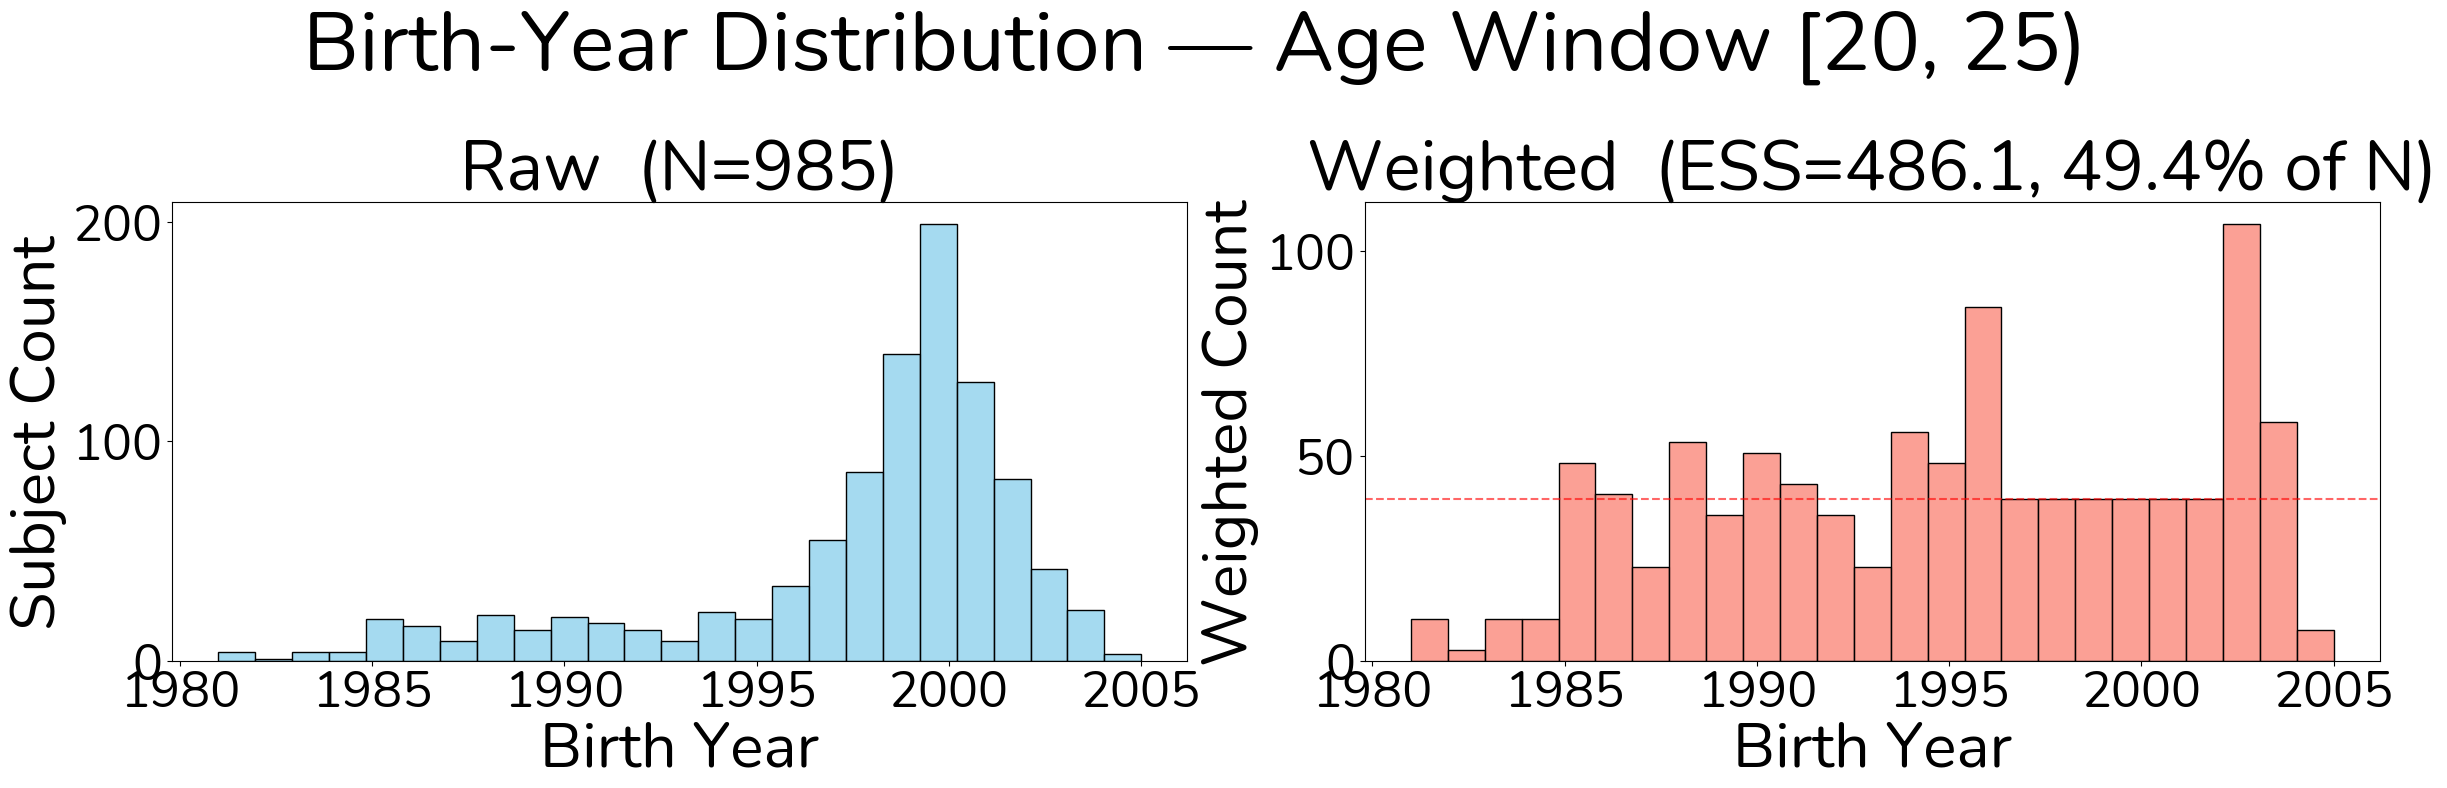

Min birth year for [25, 30): 1976
Max birth year for [25, 30): 2000
Number of subjects for [25, 30): 1082


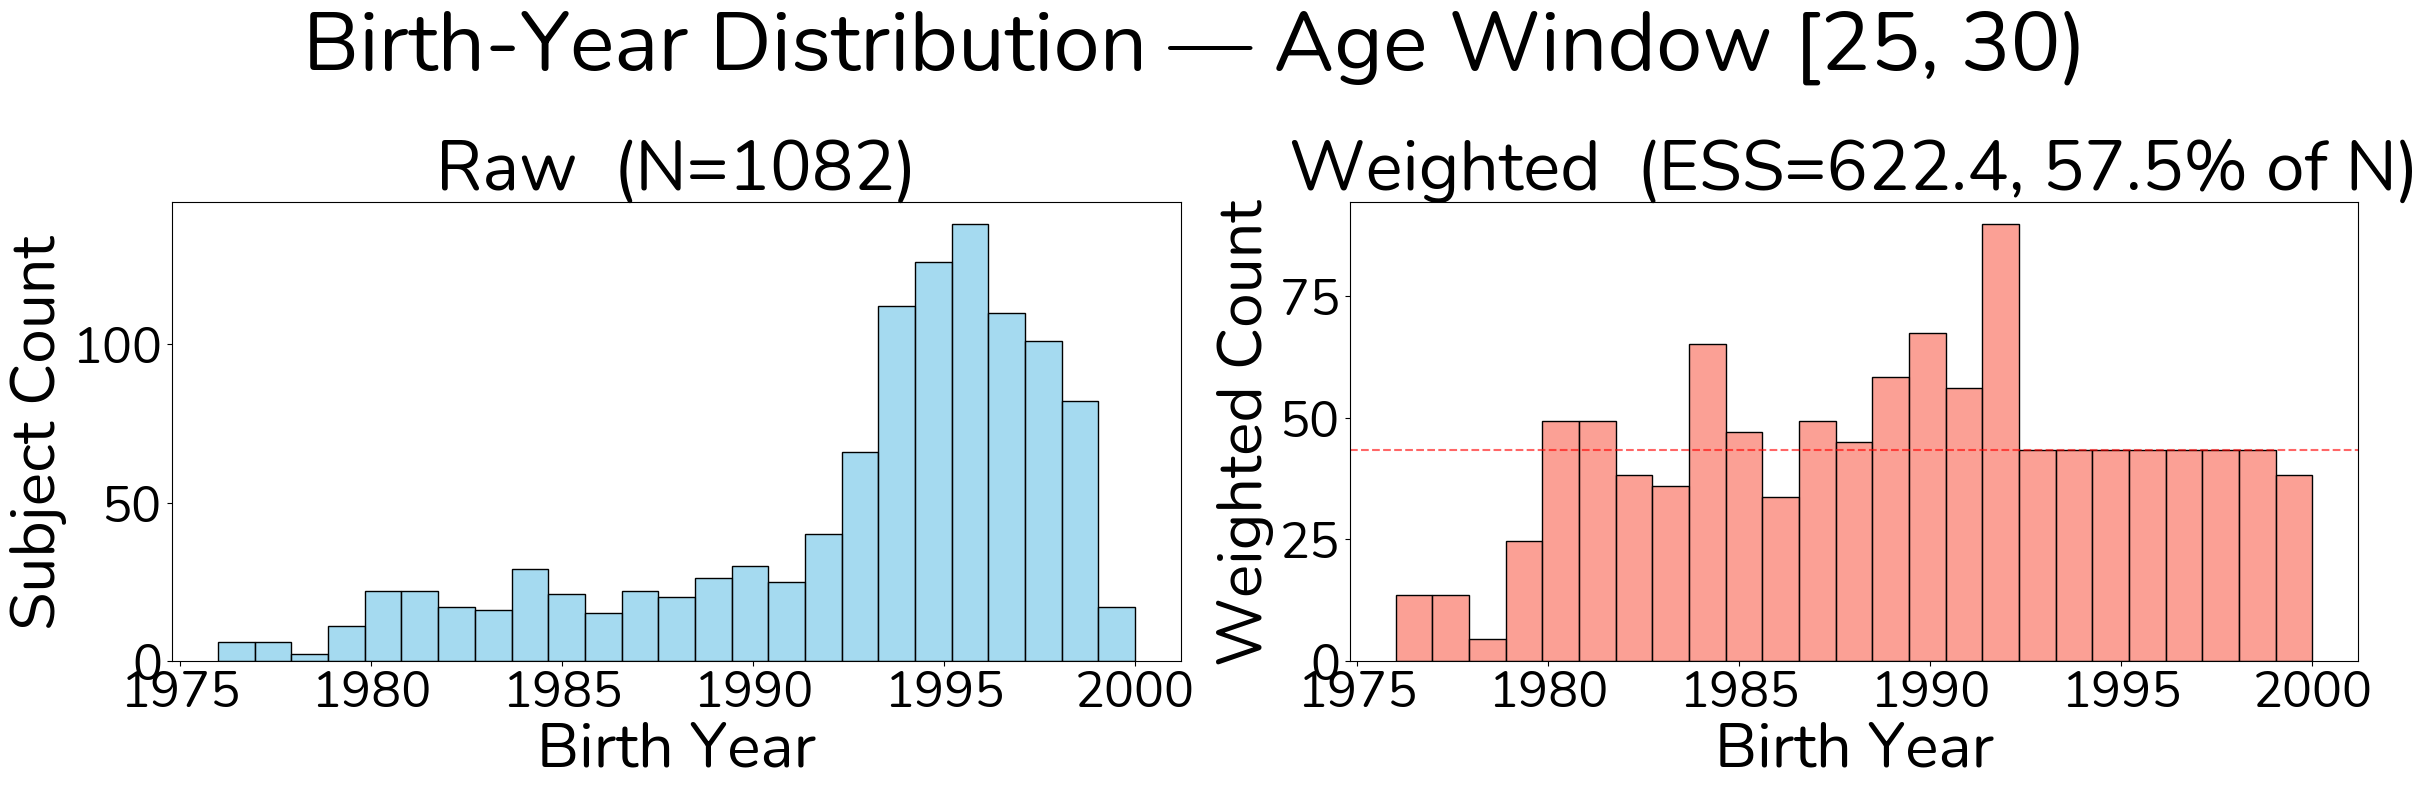

Min birth year for [30, 35): 1971
Max birth year for [30, 35): 1995
Number of subjects for [30, 35): 595


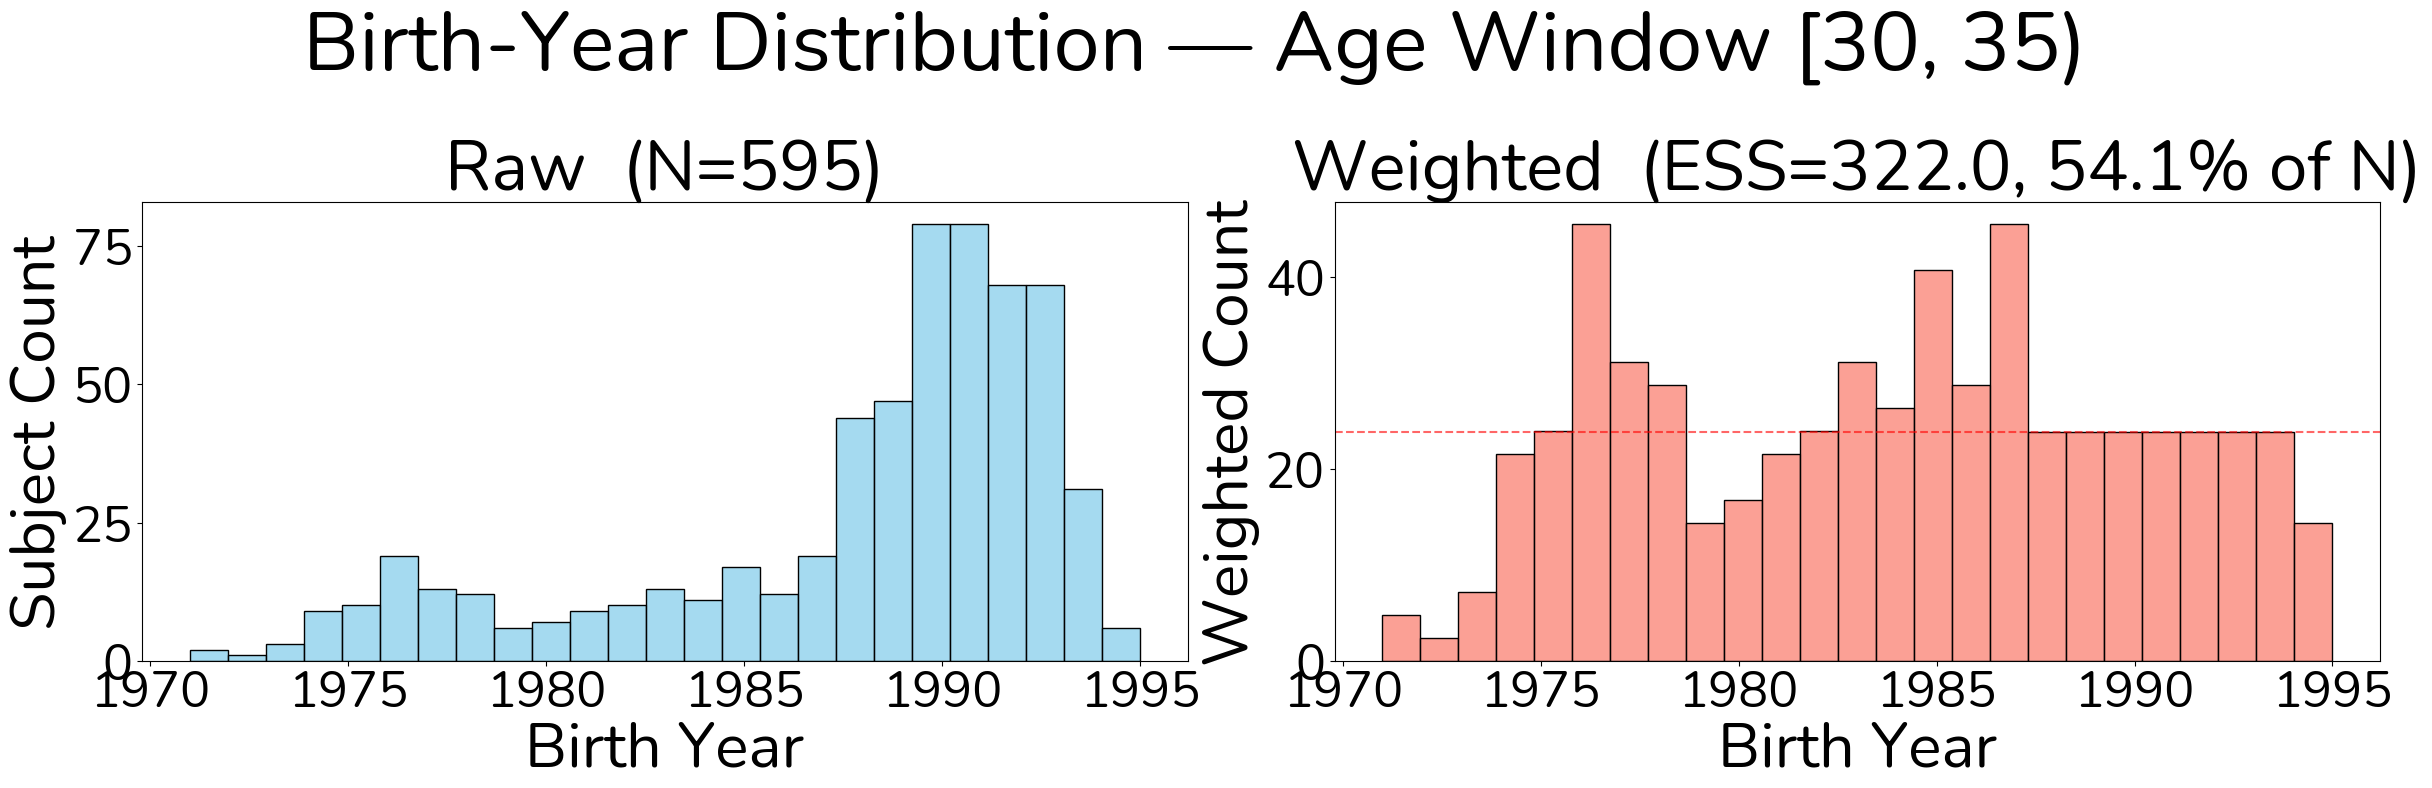

Min birth year for [35, 40): 1966
Max birth year for [35, 40): 1990
Number of subjects for [35, 40): 321


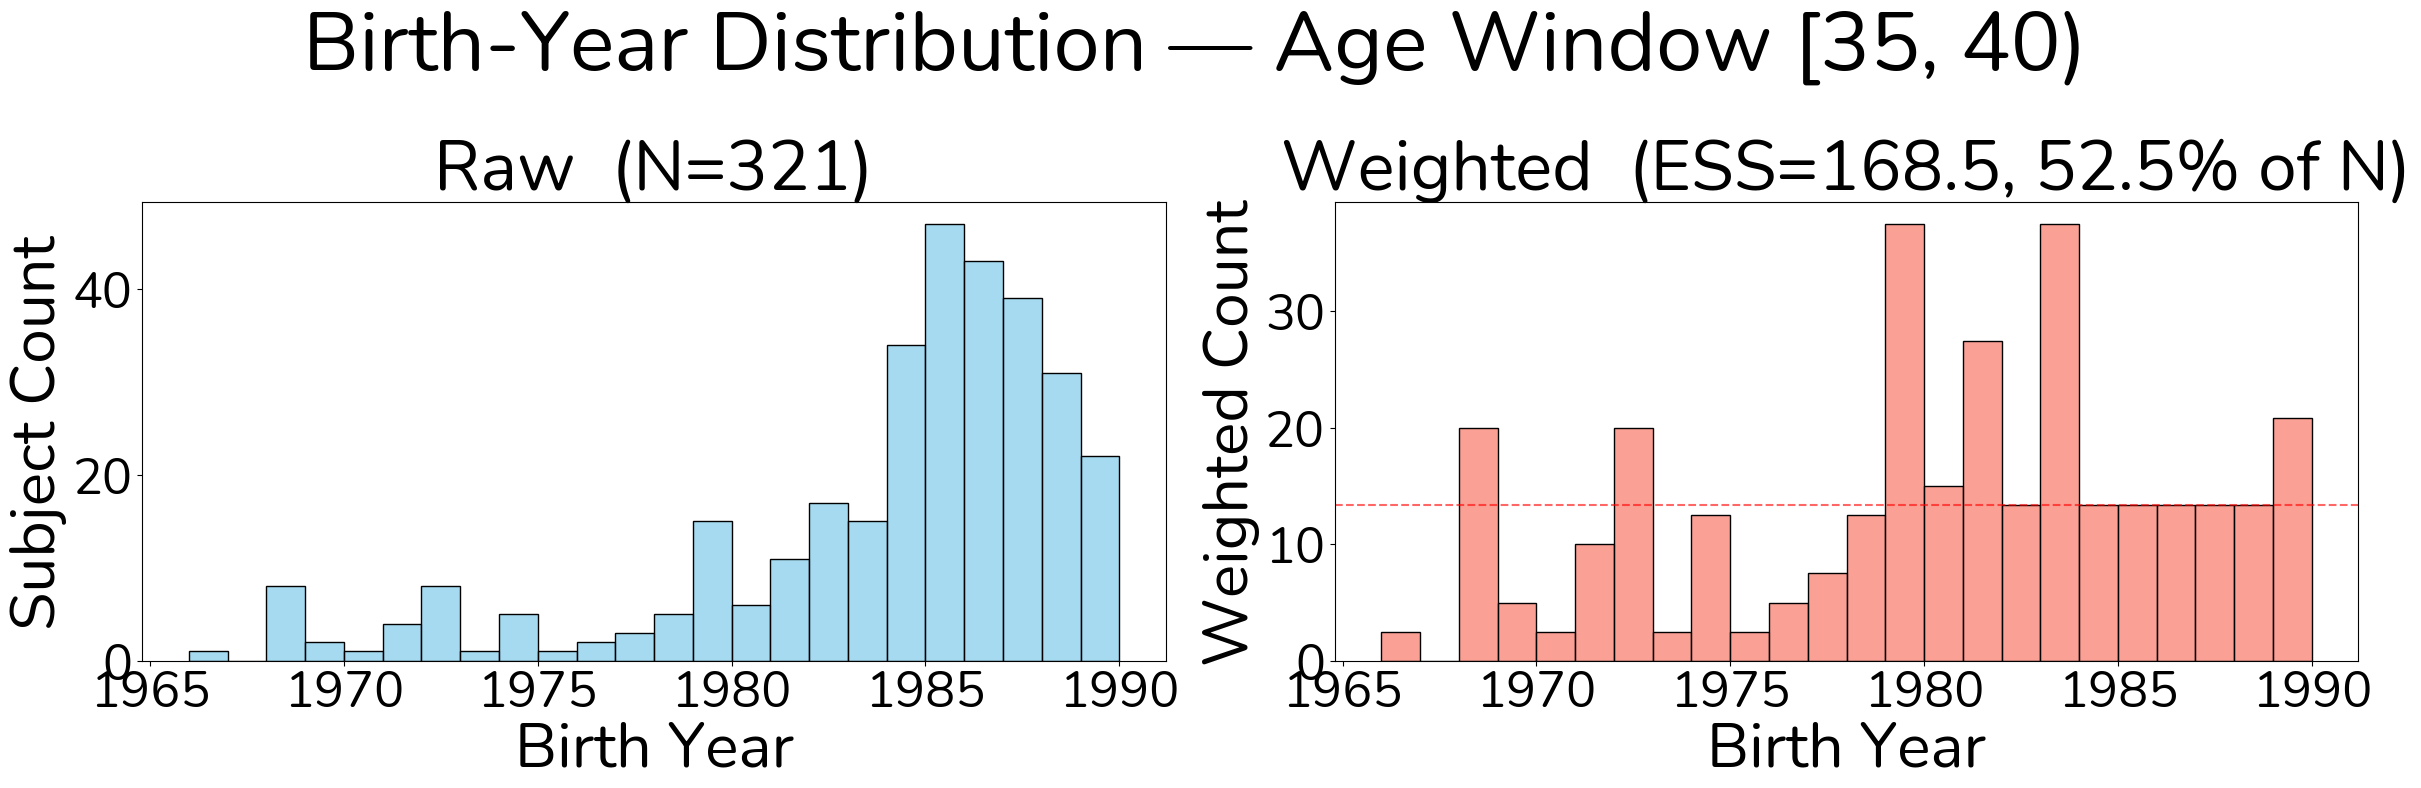

Min birth year for [40, 45): 1959
Max birth year for [40, 45): 1985
Number of subjects for [40, 45): 226


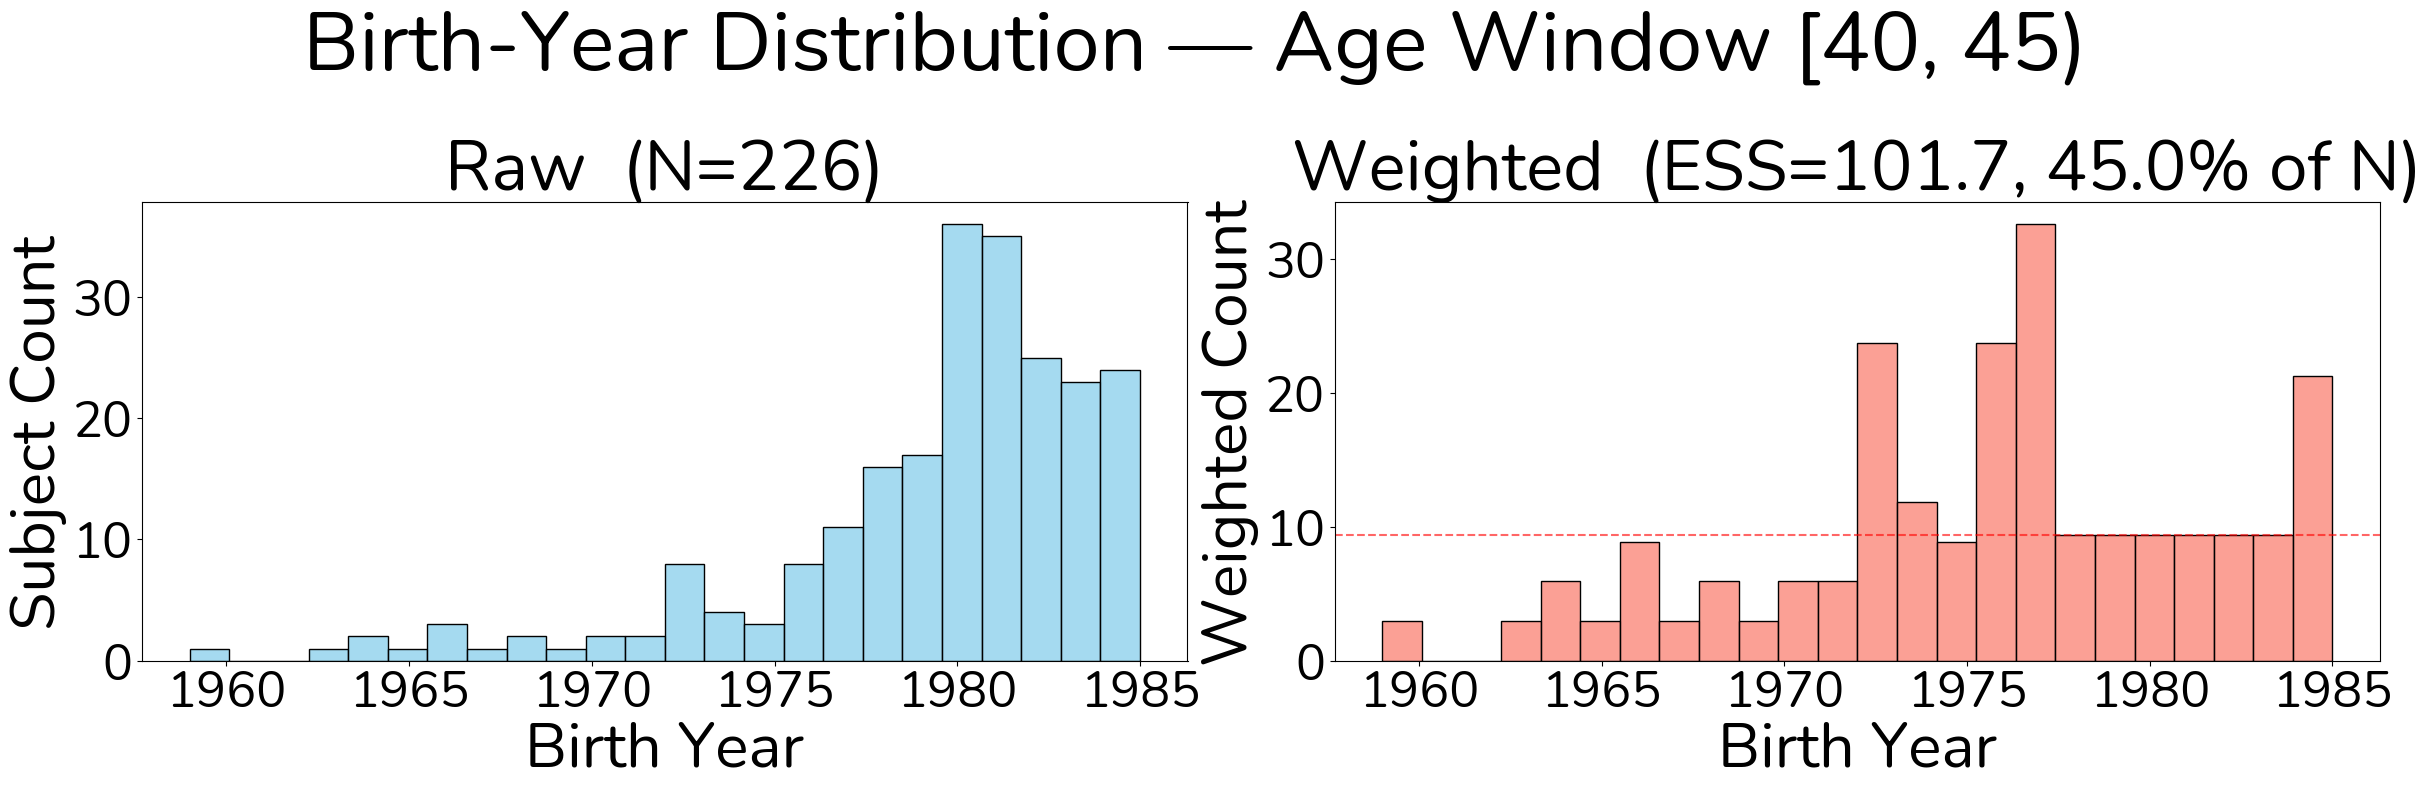

Min birth year for [45, 50): 1958
Max birth year for [45, 50): 1980
Number of subjects for [45, 50): 140


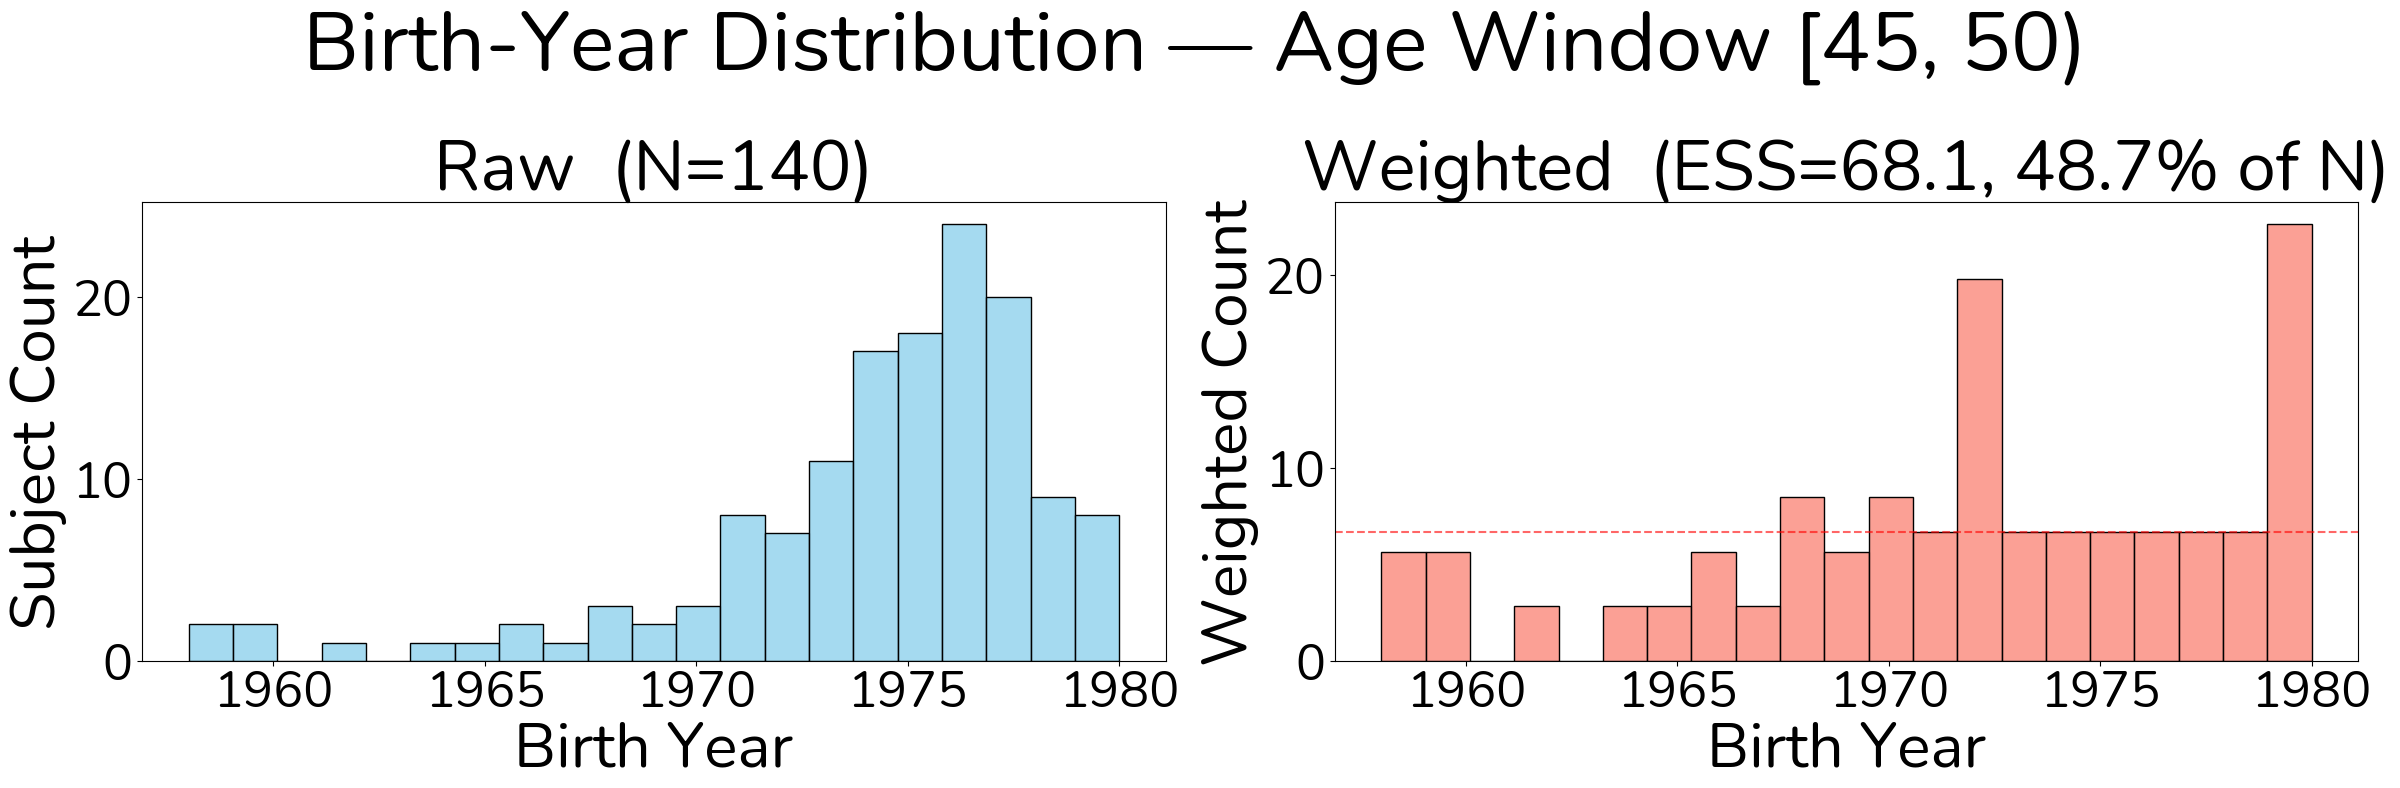

Min birth year for [50, 55): 1952
Max birth year for [50, 55): 1975
Number of subjects for [50, 55): 94


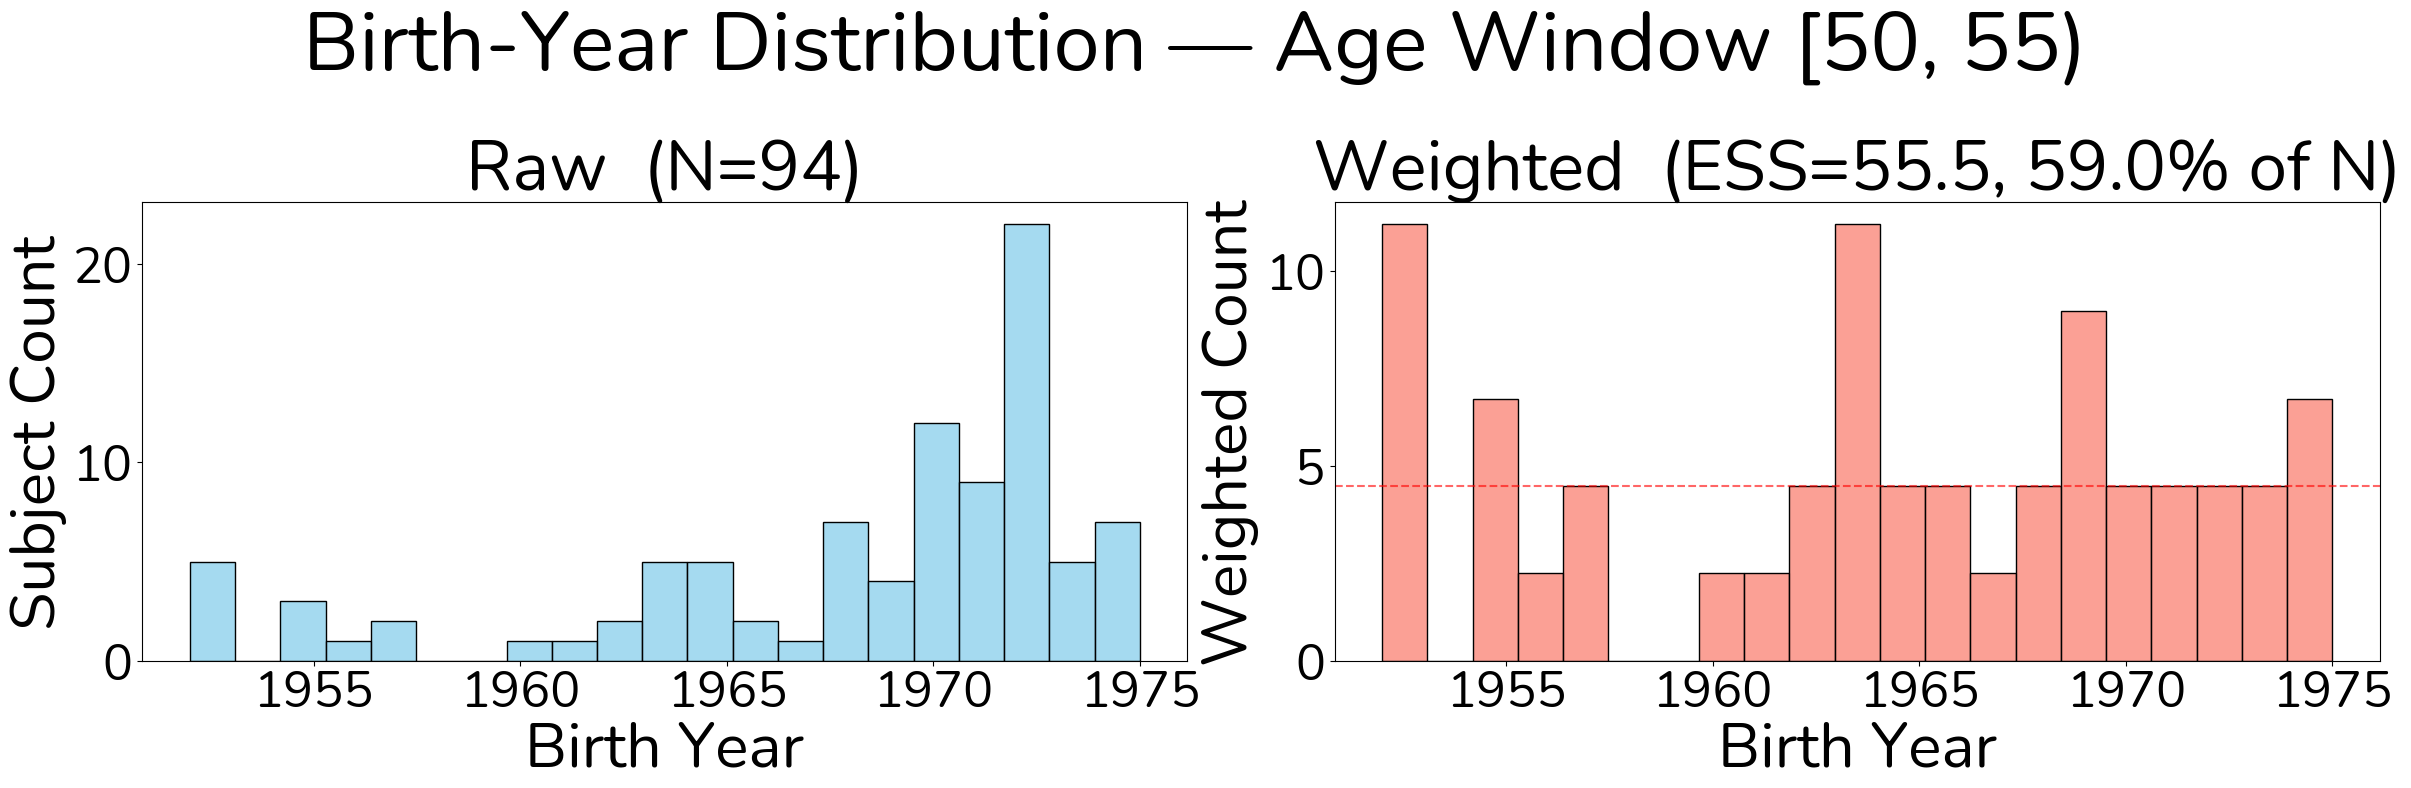

Min birth year for [55, 60): 1944
Max birth year for [55, 60): 1970
Number of subjects for [55, 60): 82


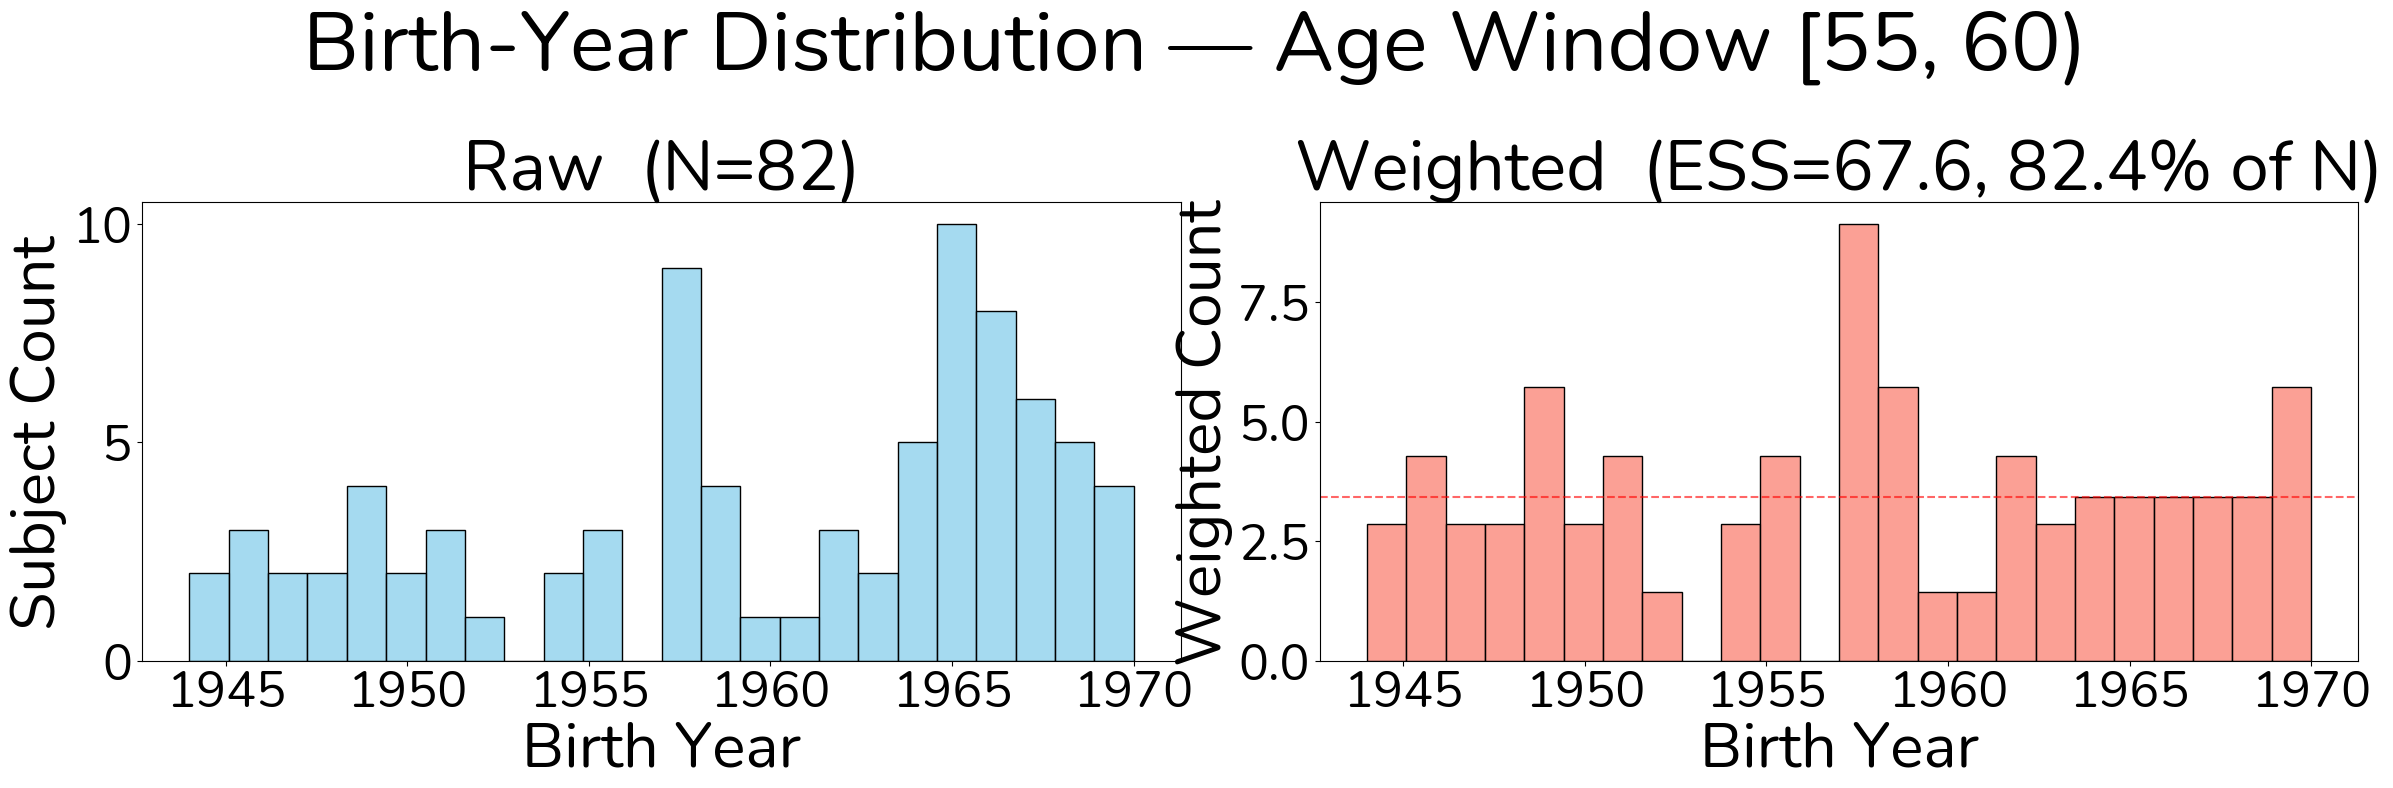

Min birth year for [60, 65): 1939
Max birth year for [60, 65): 1965
Number of subjects for [60, 65): 78


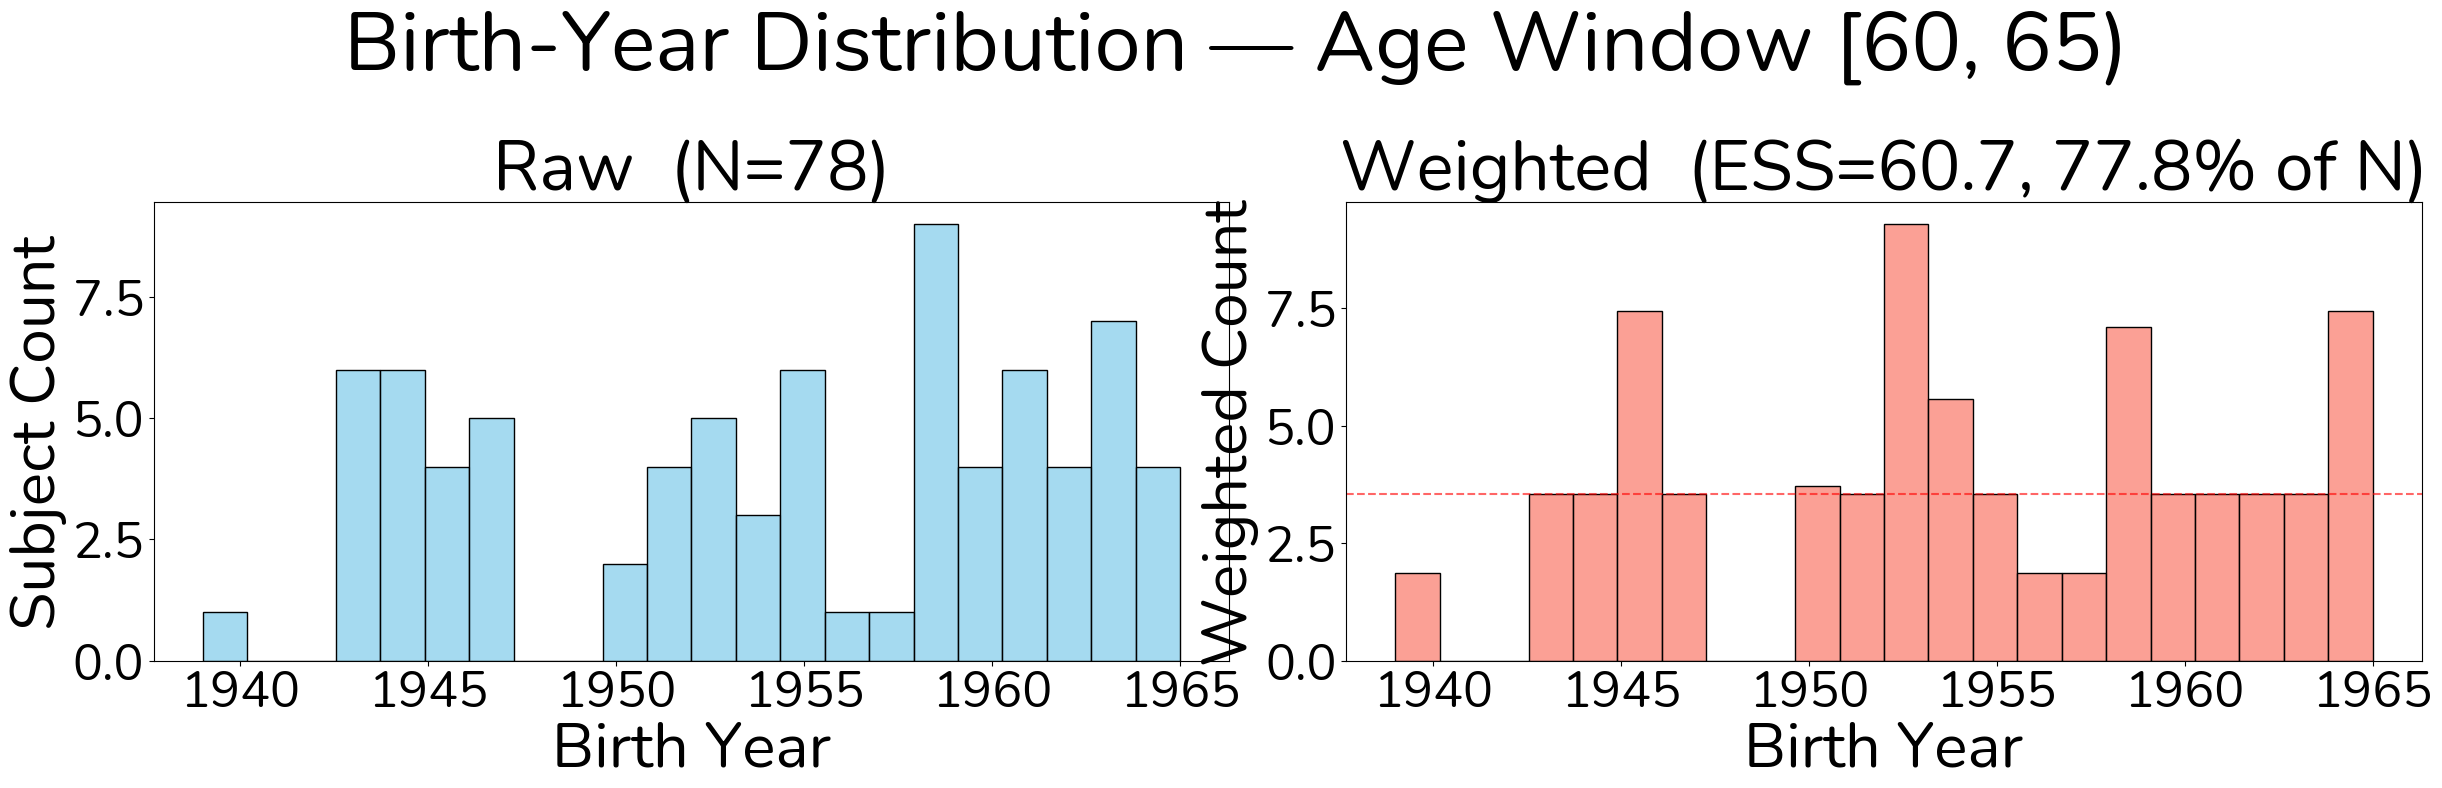

Min birth year for [65, 100): 1911
Max birth year for [65, 100): 1959
Number of subjects for [65, 100): 105


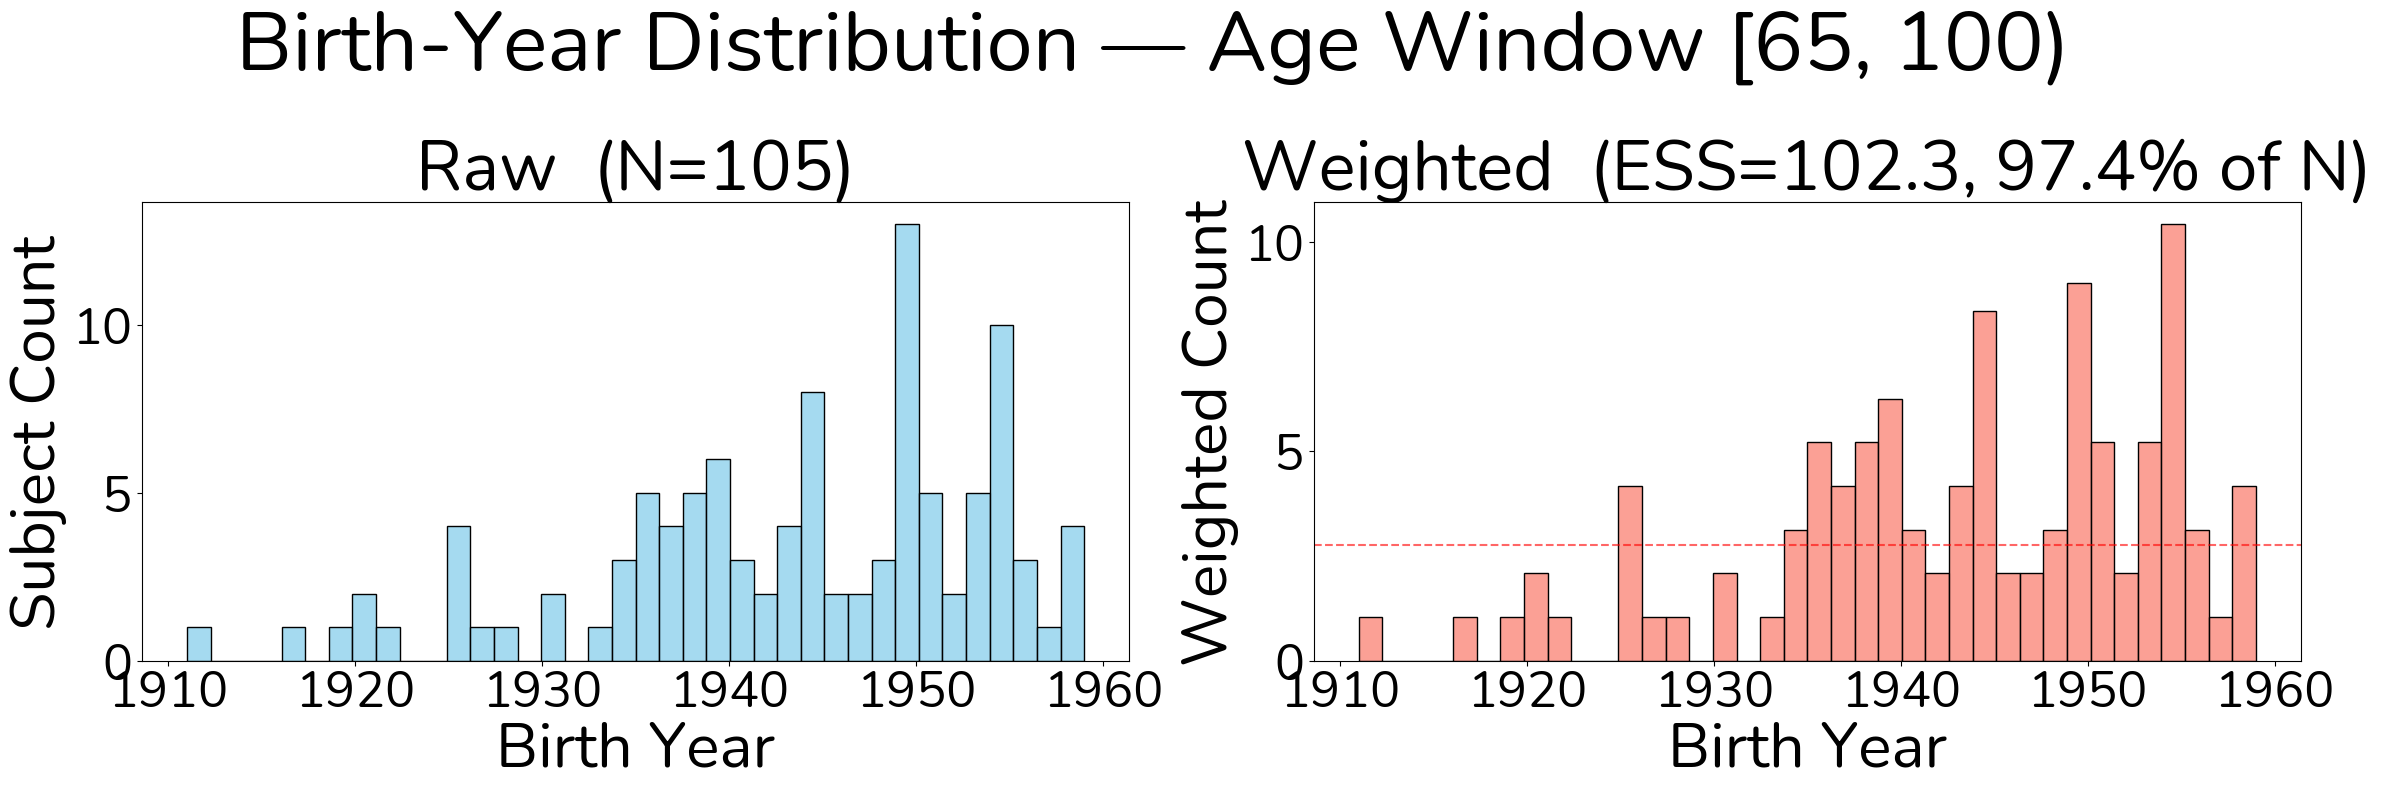

In [21]:
for bin_label, df_bin in volumes.groupby('age_bin', observed=True):
    df_window = (
        df_bin.sort_values('session_id')
        .drop_duplicates(subset=['subject_id'], keep='first')
        .copy()
    )
    print(f"Min birth year for {bin_label}: {df_window['birth_year'].min()}")
    print(f"Max birth year for {bin_label}: {df_window['birth_year'].max()}")
    print(f"Number of subjects for {bin_label}: {len(df_window)}")
    if len(df_window) < 20:
        continue
    plot_weighting_diagnostic(df_window, bin_label)

In [22]:
print(f"amount of scans with source != SNBB: {(len(volumes[volumes['source'] != 'snbb'])/454)}")
print(f"amount of scans of all sources: {(len(volumes)/454)}")

amount of scans with source != SNBB: 874.0
amount of scans of all sources: 3815.0
